In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 2. Download the dataset (if not already downloaded)
import os
import urllib.request

# Create data directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Download CPU utilization dataset
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/cpu_utilization_asg_misconfiguration.csv"
filepath = '../data/cpu_utilization_asg_misconfiguration.csv'

if not os.path.exists(filepath):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, filepath)
    print("Download complete!")
else:
    print("Dataset already exists!")

Dataset already exists!


In [3]:
# 3. Load and explore the data
df = pd.read_csv('../data/cpu_utilization_asg_misconfiguration.csv')

print("First 5 rows of data:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

First 5 rows of data:
             timestamp   value
0  2014-05-14 01:14:00  85.835
1  2014-05-14 01:19:00  88.167
2  2014-05-14 01:24:00  44.595
3  2014-05-14 01:29:00  56.282
4  2014-05-14 01:34:00  36.534

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 18050 entries, 0 to 18049
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  18050 non-null  str    
 1   value      18050 non-null  float64
dtypes: float64(1), str(1)
memory usage: 282.2 KB
None

Summary statistics:
              value
count  18050.000000
mean      38.282756
std       15.639294
min       11.529000
25%       30.789000
50%       32.001000
75%       35.660500
max      100.000000


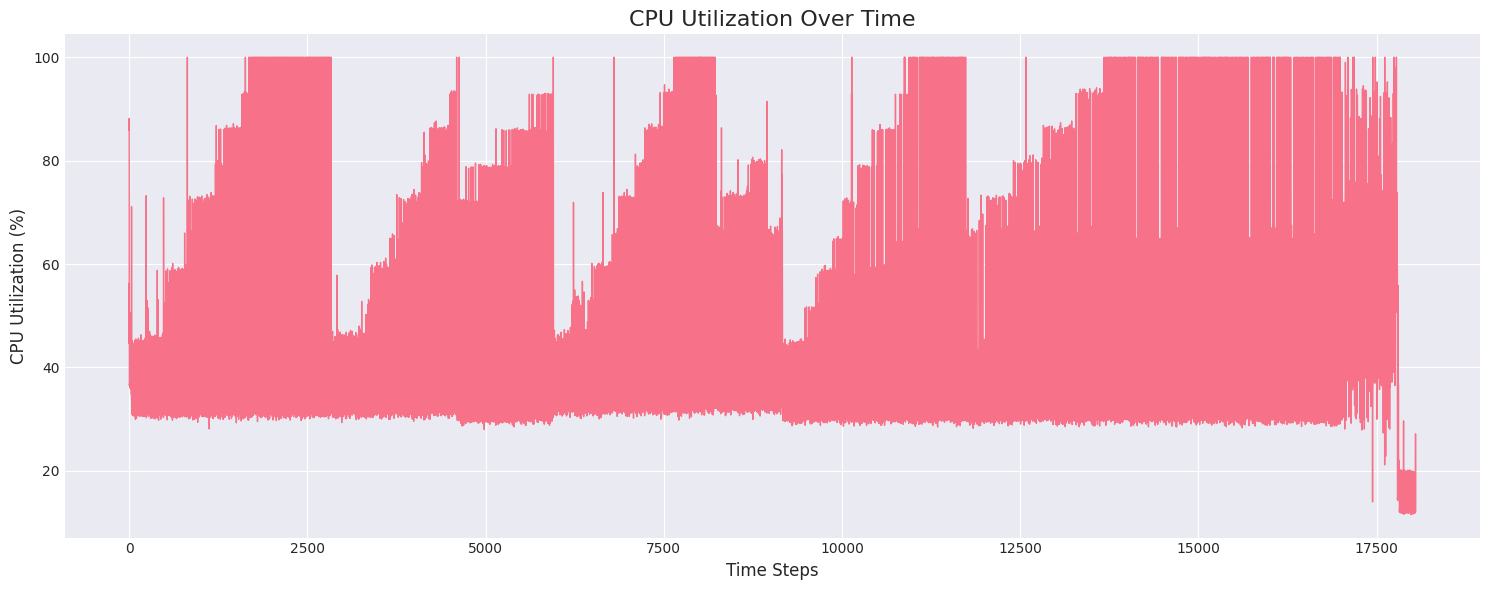

In [4]:
# 4. Visualize the time series
plt.figure(figsize=(15, 6))
plt.plot(df['value'], linewidth=1)
plt.title('CPU Utilization Over Time', fontsize=16)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('CPU Utilization (%)', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# 5. Feature engineering for time series
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Create time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['day_of_month'] = df['timestamp'].dt.day

# Create rolling statistics (window sizes appropriate for this dataset)
df['rolling_mean_5'] = df['value'].rolling(window=5, min_periods=1).mean()
df['rolling_std_5'] = df['value'].rolling(window=5, min_periods=1).std()
df['rolling_mean_20'] = df['value'].rolling(window=20, min_periods=1).mean()
df['rolling_std_20'] = df['value'].rolling(window=20, min_periods=1).std()

# Create lag features
df['lag_1'] = df['value'].shift(1)
df['lag_2'] = df['value'].shift(2)
df['lag_5'] = df['value'].shift(5)

# Fill NaN values using the new method
df = df.ffill().bfill()

print(f"Final dataframe shape: {df.shape}")
print(f"Features created: {df.columns.tolist()}")
print("\nFirst few rows with new features:")
print(df.head())

Final dataframe shape: (18050, 12)
Features created: ['timestamp', 'value', 'hour', 'day_of_week', 'day_of_month', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_20', 'rolling_std_20', 'lag_1', 'lag_2', 'lag_5']

First few rows with new features:
            timestamp   value  hour  day_of_week  day_of_month  \
0 2014-05-14 01:14:00  85.835     1            2            14   
1 2014-05-14 01:19:00  88.167     1            2            14   
2 2014-05-14 01:24:00  44.595     1            2            14   
3 2014-05-14 01:29:00  56.282     1            2            14   
4 2014-05-14 01:34:00  36.534     1            2            14   

   rolling_mean_5  rolling_std_5  rolling_mean_20  rolling_std_20   lag_1  \
0       85.835000       1.648973        85.835000        1.648973  85.835   
1       87.001000       1.648973        87.001000        1.648973  85.835   
2       72.865667      24.510865        72.865667       24.510865  88.167   
3       68.719750      21.662783        68.719

In [7]:
# 6. Prepare features for Isolation Forest
# Select features for the model
feature_columns = ['value', 'hour', 'day_of_week', 'day_of_month',
                   'rolling_mean_5', 'rolling_std_5',
                   'rolling_mean_20', 'rolling_std_20',
                   'lag_1', 'lag_2', 'lag_5']

X = df[feature_columns].values

# Standardize features (important for Isolation Forest)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Number of features: {X_scaled.shape[1]}")
print(f"Feature names: {feature_columns}")

Feature matrix shape: (18050, 11)
Number of features: 11
Feature names: ['value', 'hour', 'day_of_week', 'day_of_month', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_20', 'rolling_std_20', 'lag_1', 'lag_2', 'lag_5']


In [8]:
# 7. Train Isolation Forest model
from sklearn.ensemble import IsolationForest

# Create and train the model
model = IsolationForest(
    contamination=0.1,  # Assume 10% of data are anomalies
    random_state=42,
    n_estimators=100,
    max_samples='auto',
    bootstrap=False,
    n_jobs=-1
)

# Train the model
model.fit(X_scaled)

# Predict anomalies (-1 for anomalies, 1 for normal)
predictions = model.predict(X_scaled)

# Convert predictions to binary (1 for anomaly, 0 for normal)
anomaly_labels = [1 if x == -1 else 0 for x in predictions]

# Add predictions to dataframe
df['predicted_anomaly'] = anomaly_labels
df['anomaly_score'] = model.decision_function(X_scaled)

print(f"Number of anomalies detected: {sum(anomaly_labels)}")
print(f"Percentage anomalies: {sum(anomaly_labels)/len(anomaly_labels)*100:.2f}%")
print(f"\nAnomaly score range: [{df['anomaly_score'].min():.2f}, {df['anomaly_score'].max():.2f}]")

Number of anomalies detected: 1805
Percentage anomalies: 10.00%

Anomaly score range: [-0.16, 0.17]


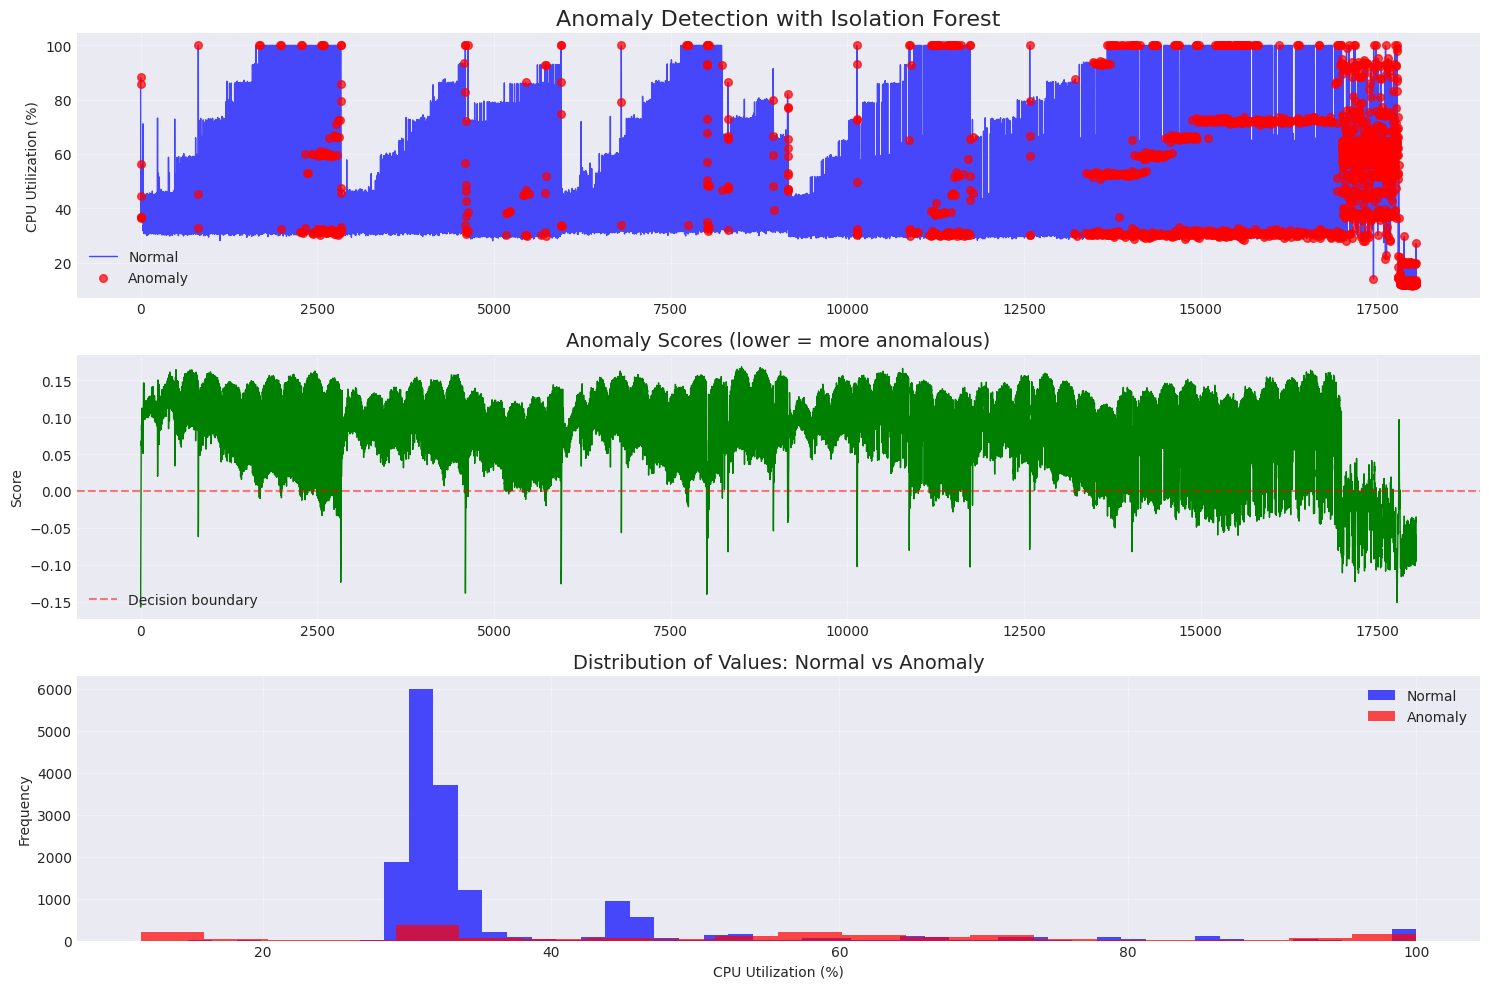

In [9]:
# 8. Visualize detected anomalies
plt.figure(figsize=(15, 10))

# Plot 1: Time series with anomalies highlighted
plt.subplot(3, 1, 1)
plt.plot(df.index, df['value'], linewidth=1, color='blue', alpha=0.7, label='Normal')

# Highlight anomalies in red
anomalies = df[df['predicted_anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['value'], 
            color='red', s=30, label='Anomaly', zorder=5, alpha=0.7)

plt.title('Anomaly Detection with Isolation Forest', fontsize=16)
plt.ylabel('CPU Utilization (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Anomaly scores
plt.subplot(3, 1, 2)
plt.plot(df.index, df['anomaly_score'], linewidth=1, color='green')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
plt.title('Anomaly Scores (lower = more anomalous)', fontsize=14)
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Distribution of values (normal vs anomaly)
plt.subplot(3, 1, 3)
normal_values = df[df['predicted_anomaly'] == 0]['value']
anomaly_values = df[df['predicted_anomaly'] == 1]['value']

plt.hist(normal_values, bins=50, alpha=0.7, label='Normal', color='blue')
plt.hist(anomaly_values, bins=20, alpha=0.7, label='Anomaly', color='red')
plt.title('Distribution of Values: Normal vs Anomaly', fontsize=14)
plt.xlabel('CPU Utilization (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# 9. Analyze anomaly statistics
print("=== Anomaly Statistics ===\n")

print(f"Total data points: {len(df)}")
print(f"Normal points: {len(df[df['predicted_anomaly'] == 0])}")
print(f"Anomalies detected: {len(df[df['predicted_anomaly'] == 1])}")

print(f"\nNormal value stats:")
print(df[df['predicted_anomaly'] == 0]['value'].describe())

print(f"\nAnomaly value stats:")
print(df[df['predicted_anomaly'] == 1]['value'].describe())

# Find the most anomalous points
print(f"\nTop 5 most anomalous points (lowest scores):")
top_anomalies = df.nsmallest(5, 'anomaly_score')[['value', 'anomaly_score', 'timestamp']]
print(top_anomalies)

=== Anomaly Statistics ===

Total data points: 18050
Normal points: 16245
Anomalies detected: 1805

Normal value stats:
count    16245.000000
mean        36.821933
std         13.356609
min         14.789000
25%         30.811000
50%         31.895000
75%         34.136000
max        100.000000
Name: value, dtype: float64

Anomaly value stats:
count    1805.000000
mean       51.430163
std        25.466575
min        11.529000
25%        30.650000
50%        52.717000
75%        66.719000
max       100.000000
Name: value, dtype: float64

Top 5 most anomalous points (lowest scores):
          value  anomaly_score           timestamp
1       88.1670      -0.157336 2014-05-14 01:19:00
0       85.8350      -0.154959 2014-05-14 01:14:00
17779  100.0000      -0.151230 2014-07-14 18:49:00
8012   100.0000      -0.139974 2014-06-10 20:54:00
17780   87.0262      -0.139872 2014-07-14 18:54:00


In [11]:
# 10. Save the trained model
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the model and scaler
model_path = '../models/isolation_forest_model.pkl'
scaler_path = '../models/scaler.pkl'

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

# Test loading the model
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
print("\n✅ Model and scaler loaded successfully!")

Model saved to: ../models/isolation_forest_model.pkl
Scaler saved to: ../models/scaler.pkl

✅ Model and scaler loaded successfully!


In [12]:
# 11. Create a function to convert anomaly score to risk percentage
def anomaly_score_to_risk(score):
    """
    Convert Isolation Forest score to risk percentage (0-100)
    Lower score = higher risk
    """
    # Scores typically range from -0.5 to 0.5
    # Map to 0-100 where lower score = higher risk
    risk = max(0, min(100, (0.5 - score) * 100))
    return risk

# Test on some examples
print("Risk Score Examples:")
print("-" * 40)
for score in [-0.4, -0.2, 0, 0.2, 0.4]:
    risk = anomaly_score_to_risk(score)
    print(f"Score: {score:5.2f} → Risk: {risk:5.1f}%")

# Apply to our data
df['risk_score'] = df['anomaly_score'].apply(anomaly_score_to_risk)

print(f"\nRisk scores in our data:")
print(f"Min risk: {df['risk_score'].min():.1f}%")
print(f"Max risk: {df['risk_score'].max():.1f}%")
print(f"Mean risk: {df['risk_score'].mean():.1f}%")

Risk Score Examples:
----------------------------------------
Score: -0.40 → Risk:  90.0%
Score: -0.20 → Risk:  70.0%
Score:  0.00 → Risk:  50.0%
Score:  0.20 → Risk:  30.0%
Score:  0.40 → Risk:  10.0%

Risk scores in our data:
Min risk: 33.2%
Max risk: 65.7%
Mean risk: 41.7%
